In [1]:
from pydantic import Field, BaseModel
from typing import List, Optional, Literal
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()
os.environ["LANGSMITH_PROJECT"] = "data-analysis-agent-testing"

python-dotenv could not parse statement starting at line 1


In [8]:
from typing import TypedDict, Annotated
from langchain_community.document_loaders.csv_loader import CSVLoader
from langchain_core.messages import (
    SystemMessage,
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
from langchain_core.output_parsers import PydanticOutputParser
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Send


class schema_for_subgraph_schema_generator(TypedDict):
    csv_schema: str
    messages: Annotated[List[BaseMessage], add_messages]

In [16]:
from langchain_ollama import OllamaLLM

llm = OllamaLLM(
    model="glm-5:cloud",
    base_url="glm-5:cloud",
    api_key="231607bbea5b4ebfa875322c62cc9e9e.sq-TQwxdY2J1REd0Ew39zyHM",
)

ModuleNotFoundError: No module named 'langchain_ollama'

In [3]:
@tool
def run_pandas_queries(
    queries: str = Field(
        ...,
        description="Multiple pandas queries separated by newlines (\\n). Each line should be a valid Python statement. Assign intermediate results to named variables for retrieval.",
    ),
    variables_to_return: List[str] = Field(
        ...,
        description="List of variable names defined in the queries whose values should be returned. Variables not found in scope will return None.",
    ),
) -> dict:
    """
    Executes a multi-line pandas query string in an isolated scope and returns
    the values of specified intermediate variables.

    This tool is designed for stepwise data exploration — you can chain multiple
    pandas operations across lines and selectively retrieve any named variable
    from the execution scope.

    Args:
        queries (str): A newline-separated string of valid Python/pandas statements.
                       Variables assigned in earlier lines are accessible in later lines.

        variables_to_return (List[str]): Names of variables from the query scope to
                                         include in the response. Any name not found
                                         in scope will be returned as None.

    Returns:
        dict: On success — {"status": "success", "<var1>": <value>, "<var2>": <value>, ...}
              On failure — {"status": "failed", "error": "<error message>"}

    Eg:
        Input:
            queries = \"\"\"
                import pandas as pd
                df = pd.read_csv('iris.csv')
                columns = df.columns
                shape = df.shape
            \"\"\"
            variables_to_return = ['columns', 'shape']

        Output:
            {
                'status': 'success',
                'columns': Index(['Id', 'SepalLengthCm', ...], dtype='object'),
                'shape': (150, 6)
            }
    """
    try:
        scope = {}
        exec(queries, {}, scope)
        result = {"status": "success"}
        for var in variables_to_return:
            result[var] = scope.get(var, None)
        return result
    except Exception as e:
        return {"status": "failed", "error": str(e)}

In [4]:
@tool
def run_graph_queries(
    queries: str = Field(
        ...,
        description="Multiple plotly or pandas queries separated by newlines (\\n). Each line should be a valid Python statement.",
    ),
):
    """
    Executes a multi-line Plotly graphing script in an isolated scope and saves
    the resulting figure as a PNG image.

    This tool is designed for stepwise chart construction — you can build and
    layer Plotly traces across multiple lines, customize layout, and persist
    the final figure by calling fig.write_image('<path>.png') within the query.

    Args:
        queries (str): A newline-separated string of valid Python/Plotly statements.
                       Variables assigned in earlier lines are accessible in later lines.
                       The script must assign the figure to `fig` and save it using
                       fig.write_image('<path>.png').

    Returns:
        dict: On success — {"status": "success"}
              On failure — {"status": "failed", "error": "<error message>"}

    Eg:
        Input:
            queries = \"\"\"
                import plotly.express as px
                import pandas as pd
                df = pd.read_csv('iris.csv')
                fig = px.scatter(df, x='SepalLengthCm', y='SepalWidthCm', color='Species')
                fig.update_layout(title='Iris Sepal Dimensions')
                fig.write_image('iris_scatter.png')
            \"\"\"

        Output:
            {"status": "success"}
    """
    try:
        scope = {}
        exec(queries, {}, scope)
        result = {"status": "success"}
        return result
    except Exception as e:
        return {"status": "failed", "error": str(e)}

In [5]:
[1, 2, *[2, 2]]

[1, 2, 2, 2]

In [6]:
sys_prompt_for_schema_generator = f"""
You are a data analysis assistant specialized in generating detailed schemas for CSV files.
The schema you produce will be used by downstream pipeline nodes to reference, query, and validate the file.

## Your Task
The user will provide a CSV file path. Use the `run_pandas_queries` tool to thoroughly explore
the file and generate a comprehensive schema based on what you observe — never guess or assume.

## What to Capture
Explore the file sufficiently to document the following:

### File-Level Metadata
- total rows, total columns, duplicate row count

### Per-Column Details
For every column in the file, document:
- **Column name**: exact name as it appears in the file
- **Data type**: pandas dtype (e.g., int64, float64, object, datetime64)
- **Semantic type**: what the column likely represents (e.g., identifier, timestamp, categorical, numeric metric)
- **Sample values**: 3–5 representative values
- **Null count & percentage**: how much data is missing
- **Unique value count**: number of distinct values
- **Range or categories**: min/max for numeric columns; top categories for object columns
- **Description**: Description about data

## Rules
- Run as many `run_pandas_queries` calls as needed — do not stop until all columns are fully documented.
- Always derive every value from tool output — never fabricate or estimate.
- If the file cannot be read, report the error in the schema's error field and stop.
- Do not include any commentary outside the required output format.
"""


def schema_generator(state: schema_for_subgraph_schema_generator):

    pr = [SystemMessage(content=sys_prompt_for_schema_generator), *state["messages"]]
    res = model_for_schema_generator.invoke(pr)

    return {"messages": [res]}

In [7]:
class schema_for_schema_formatter(BaseModel):
    schema_: str


parser_for_schema_formatter = PydanticOutputParser(
    pydantic_object=schema_for_schema_formatter
)

sys_prompt_for_schema_formatter = f"user will give you the output of an ai assistant your task is to covert it into following Output format - {parser_for_schema_formatter.get_format_instructions()}"


def schema_formatter(state: schema_for_subgraph_schema_generator):
    pr = [
        SystemMessage(content=sys_prompt_for_schema_formatter),
        HumanMessage(content=state["messages"][-1].content),
    ]
    res = model_for_schema_formatter.invoke(pr)
    res = parser_for_schema_formatter.invoke(res.content)

    return {"csv_schema": res.schema_}

In [ ]:
model_for_schema_generator = ChatNVIDIA(
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
)
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
).bind_tools([run_pandas_queries])
model_for_schema_formatter = ChatNVIDIA(
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
)
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
)

C:\Users\panka\genai_project\data_analysis_agent\daa\Lib\site-packages\langchain_nvidia_ai_endpoints\_common.py:243: UserWarning: Found mistralai/mistral-small-4-119b-2603 in available_models, but type is unknown and inference may fail.
  warnings.warn(
C:\Users\panka\genai_project\data_analysis_agent\daa\Lib\site-packages\langchain_nvidia_ai_endpoints\chat_models.py:1091: UserWarning: Model 'mistralai/mistral-small-4-119b-2603' is not known to support tools. Your tool binding may fail at inference time.
  warnings.warn(


In [9]:
def tool_call_condition(
    state: schema_for_subgraph_schema_generator,
) -> Literal["tools", "schema_formatter"]:
    if state["messages"][-1].tool_calls:
        return "tools"
    return "schema_formatter"

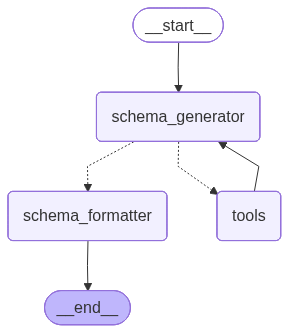

In [10]:
graph = StateGraph(schema_for_subgraph_schema_generator)

graph.add_node("schema_generator", schema_generator)
graph.add_node("schema_formatter", schema_formatter)
graph.add_node("tools", ToolNode(tools=[run_pandas_queries]))

graph.add_edge(START, "schema_generator")
graph.add_conditional_edges("schema_generator", tool_call_condition)

graph.add_edge("tools", "schema_generator")
graph.add_edge("schema_formatter", END)

check_ptr = InMemorySaver()
workflow = graph.compile(checkpointer=check_ptr)
workflow

In [11]:
# config={"configurable":{'thread_id':'2'}}
# res=workflow.invoke({'messages':[HumanMessage(content='File path = ./data/Iris.csv')]},config=config)

In [12]:
# print(res['csv_schema'])

In [13]:
class schema_for_pandas_query_generator(BaseModel):
    queries_description: List[str] = Field(
        ..., description="list of queries description"
    )


parser_for_pandas_query_generator = PydanticOutputParser(
    pydantic_object=schema_for_pandas_query_generator
)


class schema_for_graph_query_generator_util(BaseModel):
    queries_description: str = Field(..., description="querie description")
    image_name: str = Field(
        ..., description="Name of the file for chart/graph should be a png file"
    )


class schema_for_graph_query_generator(BaseModel):
    queries_description: List[schema_for_graph_query_generator_util]


parser_for_graph_query_generator = PydanticOutputParser(
    pydantic_object=schema_for_graph_query_generator
)

In [14]:
class schema_for_main_graph(TypedDict):
    file_path: str
    pandas_queries: List[schema_for_pandas_query_generator]
    graph_queries: List[schema_for_graph_query_generator]
    csv_schema: str

In [15]:
sys_prompt_for_pandas_query_generator = f"""
You are a senior data analyst specializing in statistical analysis using Python and pandas.

The user will provide a description of a CSV file. Your task is to generate descriptions of all pandas queries required to produce a comprehensive statistical analysis report of the data.

STRICT RULES:
1. Generate ONLY statistical queries — descriptive stats, distributions, correlations, aggregations, value counts, missing value analysis, outlier detection, and group-by summaries.
2. Use ONLY pandas (and numpy where necessary). No matplotlib, seaborn, plotly, or any visualization libraries.
3. Do NOT write actual code. Write clear, precise natural-language DESCRIPTIONS of each query.
4. These query descriptions will be consumed by another LLM in the next step to write the actual pandas code — so be explicit and unambiguous. Each description must be self-contained and implementation-ready.
5. Every description must specify: the operation type, the column(s) involved, and the expected output shape/format.

Output format:
{parser_for_pandas_query_generator.get_format_instructions()}
"""


def pandas_query_generator(state: schema_for_main_graph):
    pr = [
        SystemMessage(content=sys_prompt_for_pandas_query_generator),
        HumanMessage(content=f'Csv description - {state["csv_schema"]}'),
    ]

    res = model_for_query_generator.invoke(pr)
    res = parser_for_pandas_query_generator.invoke(res.content)

    return {"pandas_queries": res}

In [16]:
sys_prompt_for_graph_query_generator = f"""
You are a senior data analyst and data visualization expert specializing in exploratory data analysis (EDA).

The user will provide a description of a CSV file. Your task is to generate descriptions of all charts and graphs required to produce a comprehensive, visually rich data analysis report.

STRICT RULES:
1. Generate ONLY visualization queries — distribution plots, correlation heatmaps, bar charts, line charts, scatter plots, box plots, pair plots, pie charts, time series plots, etc.
2. Use ONLY plotly (plotly.express or plotly.graph_objects). Do NOT include any statistical computations or pandas aggregation logic.
3. Do NOT write actual code. Write clear, precise natural-language DESCRIPTIONS of each chart.
4. These chart descriptions will be consumed by another LLM in the next step to write the actual plotly code — so be explicit and unambiguous. Each description must be self-contained and implementation-ready.
5. Every description must specify:
   - Chart type and the preferred plotly module (px vs go) — e.g., "plotly.express scatter", "plotly.graph_objects Heatmap"
   - Column(s) involved (x-axis, y-axis, color/grouping if any)
   - The analytical insight this chart is meant to reveal
   - Any grouping, filtering, or sorting that should be applied before plotting

Output format:
{parser_for_graph_query_generator.get_format_instructions()}
"""


def graph_query_generator(state: schema_for_main_graph):

    pr = [
        SystemMessage(content=sys_prompt_for_graph_query_generator),
        HumanMessage(content=f'Csv description - {state["csv_schema"]}'),
    ]

    res = model_for_query_generator.invoke(pr)
    res = parser_for_graph_query_generator.invoke(res.content)

    return {"graph_queries": res}

In [ ]:
model_for_query_generator = ChatNVIDIA(
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
)
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
)

In [18]:
# x=pandas_query_generator({'csv_schema':res['csv_schema']})
# y=graph_query_generator({'csv_schema':res['csv_schema']})

In [19]:
# x['pandas_queries']

In [20]:
# y['graph_queries']

In [21]:
# sub_graph_for_pandas_query
class schema_for_pandas_query_formatter(BaseModel):
    query: str = Field(..., description="query")
    result: str = Field(..., description="result")


parser_for_pandas_query_formatter = PydanticOutputParser(
    pydantic_object=schema_for_pandas_query_formatter
)


class schema_for_pandas_query_executor(TypedDict):
    messages: Annotated[BaseMessage, add_messages]
    query: str
    formatted_result: schema_for_pandas_query_formatter

In [22]:
sys_prompt_for_pandas_query_executor = """
You are an data analyst . User will provide you a task and a csv schema Your task is to write and execute a single line/multi line pandas queries to acheive the desired output.
"""


def chat_node_for_pandas_query_executor(state: schema_for_pandas_query_executor):
    pr = [
        SystemMessage(content=sys_prompt_for_pandas_query_executor),
        *state["messages"],
    ]
    res = model_for_query_executor.invoke(pr)

    return {"messages": [res]}

In [23]:
sys_prompt_for_pandas_query_formatter = f"""
User will provide you an query and the answer generated by user for the given query your task is to format it into given format -
{parser_for_pandas_query_formatter.get_format_instructions()}
"""


def pandas_query_formator(state: schema_for_pandas_query_executor):
    pr = [
        SystemMessage(content=sys_prompt_for_pandas_query_formatter),
        HumanMessage(content=f"""
    query - {state['query']} 
    result - {state['messages'][-1].content}
    """),
    ]

    res = model_for_query_executor.invoke(pr)
    res = parser_for_pandas_query_formatter.invoke(res.content)
    return {"formatted_result": res}

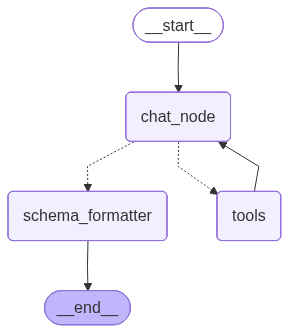

In [24]:
graph = StateGraph(schema_for_pandas_query_executor)

graph.add_node("chat_node", chat_node_for_pandas_query_executor)
graph.add_node("schema_formatter", pandas_query_formator)
graph.add_node("tools", ToolNode([run_pandas_queries]))

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tool_call_condition)
graph.add_edge("tools", "chat_node")

workflow = graph.compile(checkpointer=check_ptr)
workflow

In [25]:
# x['pandas_queries'].queries_description[0]

In [ ]:
model_for_query_executor = ChatNVIDIA(
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
)
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
).bind_tools([run_pandas_queries])

In [27]:
# res['csv_schema']

In [28]:
# query=x['pandas_queries'].queries_description[0]

# messages=HumanMessage(content=f"csv_schema: {res['csv_schema']} \n\n task:{query}")

# a=workflow.invoke({'messages':messages,'query':query},config=config)

In [29]:
# a['formatted_result']

In [30]:
# from IPython.display import display,Markdown
# display(Markdown(a['formatted_result'].result))

In [31]:
class schema_for_graph_query_executor(TypedDict):
    messages: Annotated[BaseMessage, add_messages]

In [32]:
# y['graph_queries'].queries_description[0]

In [33]:
sys_prompt_for_graph_query_executor = """
You are a data analyst. The user will provide you a task, a CSV schema, and a file path.

Your task is to write a multiline Plotly query to:
- Generate a chart, graph, or animation for the given task
- Save the figure using fig.write_image() at EXACTLY the provided file path — do not modify, append, or substitute any part of it
- Use the given tools to execute the query
"""


def chat_node_for_graph_query_executor(state: schema_for_pandas_query_executor):
    pr = [
        SystemMessage(content=sys_prompt_for_graph_query_executor),
        *state["messages"],
    ]
    res = model_for_graph_query_executor.invoke(pr)

    return {"messages": [res]}

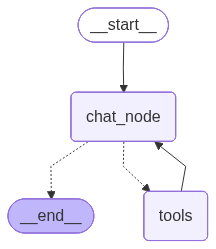

In [34]:
graph = StateGraph(schema_for_graph_query_executor)

graph.add_node("chat_node", chat_node_for_graph_query_executor)
graph.add_node("tools", ToolNode([run_graph_queries]))

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

workflow = graph.compile(checkpointer=check_ptr)
workflow

In [ ]:
model_for_graph_query_executor = ChatNVIDIA(
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
)
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
).bind_tools([run_graph_queries])

In [36]:
# message=HumanMessage(content=f"""
# task-{y['graph_queries'].queries_description[0].queries_description}
# file_path-{y['graph_queries'].queries_description[0].image_name}
# csv_schema-{res['csv_schema']}
# """)

# b=workflow.invoke({'messages':message},config=config)

In [37]:
from IPython.display import display, Markdown

display(Markdown("# Final graph"))

# Final graph

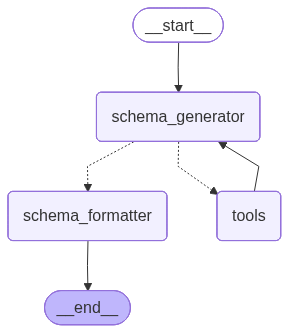

In [38]:
graph = StateGraph(schema_for_subgraph_schema_generator)

graph.add_node("schema_generator", schema_generator)
graph.add_node("schema_formatter", schema_formatter)
graph.add_node("tools", ToolNode(tools=[run_pandas_queries]))

graph.add_edge(START, "schema_generator")
graph.add_conditional_edges("schema_generator", tool_call_condition)

graph.add_edge("tools", "schema_generator")
graph.add_edge("schema_formatter", END)

schema_generator_workflow = graph.compile()
schema_generator_workflow

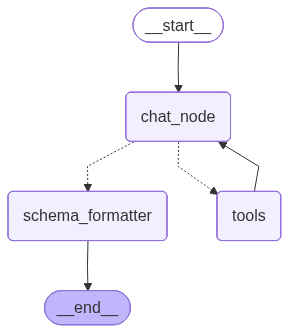

In [39]:
graph = StateGraph(schema_for_pandas_query_executor)

graph.add_node("chat_node", chat_node_for_pandas_query_executor)
graph.add_node("schema_formatter", pandas_query_formator)
graph.add_node("tools", ToolNode([run_pandas_queries]))

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tool_call_condition)
graph.add_edge("tools", "chat_node")

workflow_for_pandas_query = graph.compile()
workflow_for_pandas_query

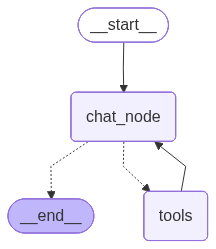

In [40]:
graph = StateGraph(schema_for_graph_query_executor)

graph.add_node("chat_node", chat_node_for_graph_query_executor)
graph.add_node("tools", ToolNode([run_graph_queries]))

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

workflow_for_graph_query = graph.compile()
workflow_for_graph_query

In [41]:
import operator


class schema_for_main_graph(TypedDict):
    file_path: str
    pandas_queries: List[schema_for_pandas_query_generator]
    graph_queries: List[schema_for_graph_query_generator]
    pandas_results: Annotated[List[schema_for_pandas_query_formatter], operator.add]
    csv_schema: str
    markdown_generator: str

In [42]:
def wrapper_for_schema_generator(state: schema_for_main_graph):
    res = schema_generator_workflow.invoke(
        {"messages": [HumanMessage(content=f'File path = {state["file_path"]}')]}
    )
    # print(res['csv_schema'])
    return {"csv_schema": res["csv_schema"]}

In [43]:
def wrapper_for_pandas_query_executor(inp):
    query = inp["query"]
    csv_schema = inp["csv_schema"]

    messages = HumanMessage(content=f"csv_schema: {csv_schema} \n\n task:{query}")

    res = workflow_for_pandas_query.invoke({"messages": [messages], "query": query})
    return {"pandas_results": [res["formatted_result"]]}

In [44]:
def fanout_for_pandas_query(state: schema_for_main_graph):
    res = []
    for pd_q in state["pandas_queries"]:
        res.append(
            Send(
                "wrapper_for_pandas_query_executor",
                {"csv_schema": state["csv_schema"], "query": pd_q},
            )
        )
    return res

In [45]:
def wrapper_for_graph_query_executor(inp):
    task = inp["task"]
    file_path = inp["file_path"]
    csv_schema = inp["csv_schema"]

    messages = HumanMessage(content=f"""
        task-{task}
        file_path-{f"./data/{file_path}"}
        csv_schema-{csv_schema}
""")

    res = workflow_for_graph_query.invoke({"messages": [messages]})
    return

In [46]:
def fanout_for_graph_query(state: schema_for_main_graph):
    res = []
    for pd_q in state["graph_queries"].queries_description:
        res.append(
            Send(
                "wrapper_for_graph_query_executor",
                {
                    "csv_schema": state["csv_schema"],
                    "task": pd_q.queries_description,
                    "file_path": pd_q.image_name,
                },
            )
        )
    return res

In [47]:
def dummy_collector(state: schema_for_main_graph):
    return

In [76]:
class schema_for_markdown_generator(BaseModel):
    markdown: str = Field(..., description="markdown file")


parser_for_markdown_generator = PydanticOutputParser(
    pydantic_object=schema_for_markdown_generator
)

sys_prompt_for_markdown_generator = f"""
You are a Markdown report generator. The user will provide you with:
- A CSV schema
- Pandas queries and their outputs
- Plotly graph queries and the file paths of the saved chart images

Your task is to produce a beautiful, well-structured, and informative Markdown analysis report of the CSV file.

Follow these guidelines when generating the report:
- Begin with a title and a brief overview of the dataset
- Organise the report into clear sections (e.g., Dataset Overview, Key Statistics, Visual Insights)
- Present query outputs as clean Markdown tables wherever applicable
- Embed saved chart images using the exact provided file paths — do not alter or substitute any part of the path
- Add concise, meaningful commentary under each section to interpret the data and charts
- Use headers, dividers, and formatting to ensure the report is easy to read and visually polished

Output format- 
{parser_for_markdown_generator.get_format_instructions()}
"""


def markdown_generator(state: schema_for_main_graph):
    po = ""
    for i in state["pandas_results"]:
        po = po + f"query= {i.query}" + f"\n result= {i.result}\n\n"

    gq = ""
    for i in state["graph_queries"].queries_description:
        gq = (
            gq
            + "\n"
            + i.queries_description
            + "\n"
            + f"File path = ./data/{i.image_name}"
            + "\n"
        )
    pr = f"""
    Csv schema - 
    {state['csv_schema']}



    Pandas queries and output - 
    {po}

    
    graph queries and output - 
    {gq}
    """

    # print(pr)
    pr = [
        SystemMessage(content=sys_prompt_for_markdown_generator),
        HumanMessage(content=pr),
    ]
    res = model_for_markdown_generator.invoke(pr)
    res = parser_for_markdown_generator.invoke(res)

    with open("markdown.md", "w") as f:
        f.write(res.markdown)

    return {"markdown": res.markdown}

In [50]:
model_for_markdown_generator = ChatNVIDIA(
    model="mistralai/mistral-small-4-119b-2603", max_completion_tokens=10000
)

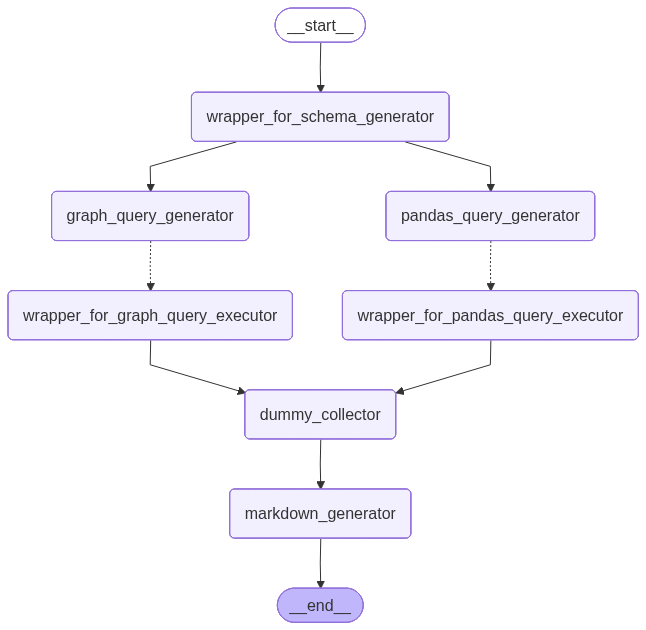

In [51]:
graph = StateGraph(schema_for_main_graph)

graph.add_node("wrapper_for_schema_generator", wrapper_for_schema_generator)
graph.add_node("pandas_query_generator", pandas_query_generator)
graph.add_node("graph_query_generator", graph_query_generator)
graph.add_node("wrapper_for_pandas_query_executor", wrapper_for_pandas_query_executor)
graph.add_node("wrapper_for_graph_query_executor", wrapper_for_graph_query_executor)
graph.add_node("dummy_collector", dummy_collector)
graph.add_node("markdown_generator", markdown_generator)
# graph.add_node('tools',ToolNode(tools=[run_pandas_queries,run_graph_queries]))

graph.add_edge(START, "wrapper_for_schema_generator")
graph.add_edge("wrapper_for_schema_generator", "pandas_query_generator")
graph.add_edge("wrapper_for_schema_generator", "graph_query_generator")

graph.add_conditional_edges(
    "pandas_query_generator",
    fanout_for_pandas_query,
    ["wrapper_for_pandas_query_executor"],
)
graph.add_conditional_edges(
    "graph_query_generator",
    fanout_for_graph_query,
    ["wrapper_for_graph_query_executor"],
)

graph.add_edge("wrapper_for_graph_query_executor", "dummy_collector")
graph.add_edge("wrapper_for_pandas_query_executor", "dummy_collector")
graph.add_edge("dummy_collector", "markdown_generator")
graph.add_edge("markdown_generator", END)

check_ptr = InMemorySaver()
workflow = graph.compile(checkpointer=check_ptr)
workflow

In [52]:
config = {"configurable": {"thread_id": "1"}}
r = workflow.invoke({"file_path": "./data/Iris.csv"}, config=config)

Resorting to unclean kill browser.
Resorting to unclean kill browser.
Resorting to unclean kill browser.
Resorting to unclean kill browser.
Resorting to unclean kill browser.
Resorting to unclean kill browser.
Resorting to unclean kill browser.
Resorting to unclean kill browser.


TypeError: BaseChatModel.invoke() missing 1 required positional argument: 'input'

In [53]:
res = workflow.invoke(None, config=config)

Deserializing unregistered type __main__.schema_for_graph_query_generator from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'schema_for_graph_query_generator')]
Deserializing unregistered type __main__.schema_for_pandas_query_generator from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'schema_for_pandas_query_generator')]
Deserializing unregistered type __main__.schema_for_pandas_query_formatter from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'schema_for_pandas_query_formatter')]


TypeError: BaseChatModel.invoke() missing 1 required positional argument: 'input'

In [54]:
r = workflow.get_state(config=config)

Deserializing unregistered type __main__.schema_for_graph_query_generator from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'schema_for_graph_query_generator')]
Deserializing unregistered type __main__.schema_for_pandas_query_generator from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'schema_for_pandas_query_generator')]
Deserializing unregistered type __main__.schema_for_pandas_query_formatter from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'schema_for_pandas_query_formatter')]


In [64]:
markdown_generator(r.values)

TypeError: object of type 'schema_for_pandas_query_formatter' has no len()

In [61]:
r.values["pandas_queries"].queries_description

['Calculate the descriptive statistics (count, mean, std, min, max, quartiles) for all numeric columns (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm). Output as a DataFrame with columns for each statistic and rows for each numeric column.',
 "Count the occurrences of each unique value in the 'Species' column. Output as a DataFrame with two columns: 'Species' and 'count', sorted in descending order of count.",
 'Count the number of missing values in each column of the dataset. Output as a Series with column names as index and missing value counts as values.',
 "Calculate the summary statistics (count, mean, std, min, 25th percentile, 50th percentile, 75th percentile, max) for each numeric column grouped by the 'Species' column. Output as a DataFrame with 'Species' as the group index and columns for each numeric column.",
 'Calculate the correlation matrix for the numeric columns (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm). Output as a DataFrame where both rows